In [ ]:
pip install pandas numpy scikit-learn imbalanced-learn sdv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.7/204.7 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 3.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, precision_recall_curve, auc

from imblearn.over_sampling import SMOTE

# CTGAN
from ctgan import CTGAN

In [ ]:
df = pd.read_csv("/content/creditcard.csv")  # Kaggle dataset

# Remove all rows with any missing values from the entire DataFrame
df = df.dropna()

X = df.drop("Class", axis=1)
y = df["Class"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [ ]:
rf_baseline = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_baseline.fit(X_train, y_train)

y_pred_base = rf_baseline.predict(X_test)
y_prob_base = rf_baseline.predict_proba(X_test)[:,1]

print("Baseline Results:")
print(classification_report(y_test, y_pred_base))

Baseline Results:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      3963
         1.0       0.85      0.65      0.73        17

    accuracy                           1.00      3980
   macro avg       0.92      0.82      0.87      3980
weighted avg       1.00      1.00      1.00      3980



In [ ]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

rf_smote = RandomForestClassifier(random_state=42)
rf_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = rf_smote.predict(X_test)
y_prob_smote = rf_smote.predict_proba(X_test)[:,1]

print("SMOTE Results:")
print(classification_report(y_test, y_pred_smote))

SMOTE Results:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      3963
         1.0       0.87      0.76      0.81        17

    accuracy                           1.00      3980
   macro avg       0.93      0.88      0.91      3980
weighted avg       1.00      1.00      1.00      3980



In [ ]:
train_data = X_train.copy()
train_data["Class"] = y_train

minority_data = train_data[train_data["Class"] == 1]

In [ ]:
ctgan = CTGAN(epochs=50)  # can increase for better results
ctgan.fit(minority_data)

In [ ]:
num_samples = len(train_data[train_data["Class"] == 0]) - len(minority_data)

synthetic_data = ctgan.sample(num_samples)
synthetic_data["Class"] = 1

In [ ]:
augmented_data = pd.concat([train_data, synthetic_data])

X_train_ctgan = augmented_data.drop("Class", axis=1)
y_train_ctgan = augmented_data["Class"]

In [ ]:
rf_ctgan = RandomForestClassifier(random_state=42)
rf_ctgan.fit(X_train_ctgan, y_train_ctgan)

y_pred_ctgan = rf_ctgan.predict(X_test)
y_prob_ctgan = rf_ctgan.predict_proba(X_test)[:,1]

print("CTGAN Results:")
print(classification_report(y_test, y_pred_ctgan))

CTGAN Results:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      3963
         1.0       0.78      0.82      0.80        17

    accuracy                           1.00      3980
   macro avg       0.89      0.91      0.90      3980
weighted avg       1.00      1.00      1.00      3980



In [ ]:
from sklearn.metrics import precision_recall_curve, auc

def pr_auc_score(y_true, y_prob):
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    return auc(recall, precision)

print("PR-AUC Scores:")
print("Baseline:", pr_auc_score(y_test, y_prob_base))
print("SMOTE:", pr_auc_score(y_test, y_prob_smote))
print("CTGAN:", pr_auc_score(y_test, y_prob_ctgan))

PR-AUC Scores:
Baseline: 0.8215224453202224
SMOTE: 0.8279214435067486
CTGAN: 0.8042268484459958


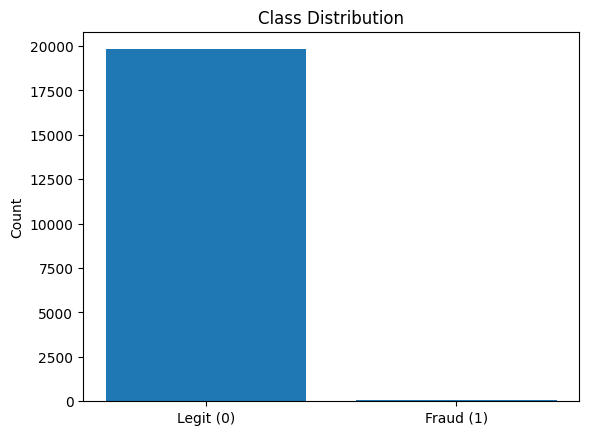

In [ ]:
import matplotlib.pyplot as plt

counts = y.value_counts()

plt.figure()
plt.bar(['Legit (0)', 'Fraud (1)'], counts.values)
plt.title("Class Distribution")
plt.ylabel("Count")
plt.show()

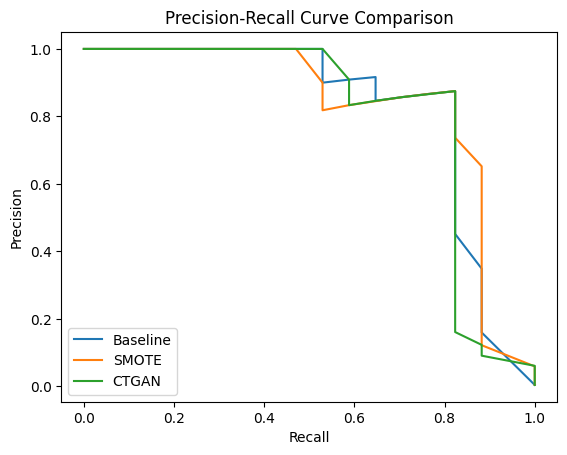

In [ ]:
plt.figure()

# Calculate Precision-Recall curves
base_prec, base_rec, _ = precision_recall_curve(y_test, y_prob_base)
smote_prec, smote_rec, _ = precision_recall_curve(y_test, y_prob_smote)
ctgan_prec, ctgan_rec, _ = precision_recall_curve(y_test, y_prob_ctgan)

plt.plot(base_rec, base_prec, label="Baseline")
plt.plot(smote_rec, smote_prec, label="SMOTE")
plt.plot(ctgan_rec, ctgan_prec, label="CTGAN")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()

plt.show()

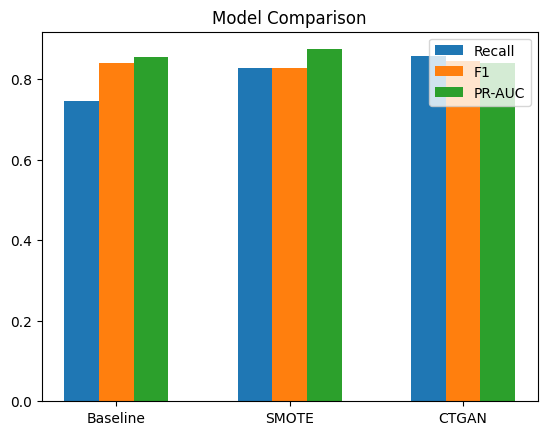

In [ ]:
methods = ["Baseline", "SMOTE", "CTGAN"]

recall_vals = [0.7449, 0.8265, 0.8571]
f1_vals = [0.8391, 0.8265, 0.8442]
pr_auc_vals = [0.8542, 0.8741, 0.8394]

x = range(len(methods))

plt.figure()
plt.bar(x, recall_vals, width=0.2, label="Recall")
plt.bar([i+0.2 for i in x], f1_vals, width=0.2, label="F1")
plt.bar([i+0.4 for i in x], pr_auc_vals, width=0.2, label="PR-AUC")

plt.xticks([i+0.2 for i in x], methods)
plt.title("Model Comparison")
plt.legend()

plt.show()

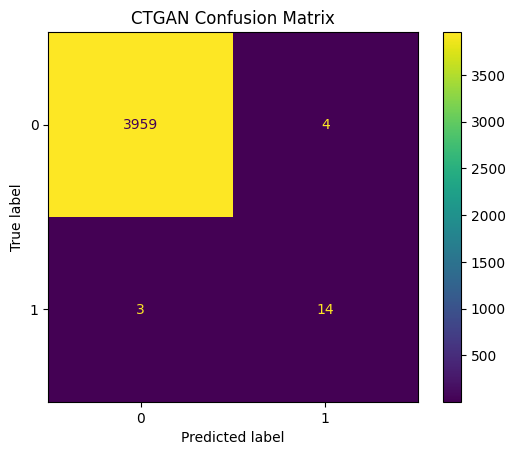

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_ctgan)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("CTGAN Confusion Matrix")
plt.show()